<a href="https://colab.research.google.com/github/davidoca2000-source/Analitica_de_Negocios/blob/main/Prcial_Final_Wine_Quality_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Análisis Base de Datos: Wine Quality Dataset
### Analítica de Negocios — Proyecto Final
---
**Dataset:** Wine Quality — Kaggle  
**Modelos usados:** Naive Bayes (Clasificación) + K-Means (Agrupamiento)  
**Objetivo:** Apoyar la toma de decisiones de una empresa vitivinícola para clasificar y segmentar vinos según su calidad

##1. Contexto de la Base de Datos

El **Wine Quality Dataset** recopila características físico-químicas de vinos tintos y blancos, junto con una puntuación de calidad asignada por catadores expertos.

**¿Por qué es importante para una organización?**  
Una empresa vitivinícola puede usar estos modelos para:
- Predecir automáticamente si un vino será de buena o mala calidad antes de lanzarlo al mercado
- Identificar qué características químicas definen un vino de alta calidad
- Segmentar su portafolio de vinos para estrategias de precios y marketing
- Optimizar el proceso de producción reduciendo costos de catadores humanos

**Fuente:** [Kaggle — Wine Quality Dataset](https://www.kaggle.com/datasets/rajyellow46/wine-quality)

##Variables categóricas explicativas

- type: Indica el tipo de vino que se está analizando. Valores posibles: Red (Tinto) / White (Blanco)


##Variables numéricas explicativas

- fixed acidity: Cantidad de ácidos fijos presentes en el vino. Influye en el sabor y la estabilidad del producto.

- volatile acidity: Cantidad de ácido acético (vinagre) en el vino. Un nivel alto genera un sabor desagradable.

- citric acid: Cantidad de ácido cítrico. Aporta frescura y sabor al vino. Se encuentra en pequeñas cantidades.

- residual sugar: Cantidad de azúcar que queda después de la fermentación. Determina qué tan dulce es el vino.

- chlorides: Cantidad de sal presente en el vino. Niveles altos pueden afectar negativamente el sabor.

- free sulfur dioxide: Cantidad de dióxido de azufre libre. Actúa como conservante y protege el vino de bacterias.

- total sulfur dioxide: Cantidad total de dióxido de azufre (libre y combinado). En altas concentraciones afecta el olor.

- density: Densidad del vino en relación con el agua. Está relacionada con el contenido de alcohol y azúcar.

- pH: Mide el nivel de acidez del vino en una escala de 0 a 14. La mayoría de los vinos tienen pH entre 3 y 4.

- sulphates: Aditivo que contribuye a los niveles de dióxido de azufre. Actúa como antimicrobiano y antioxidante.

- alcohol: Porcentaje de contenido de alcohol del vino. Influye directamente en el cuerpo y sabor.

##Variable explicativa numérica de pronóstico

- quality: Puntuación de calidad asignada por catadores expertos. En el modelo se convierte en binaria: 0 = Mala calidad (≤5) / 1 = Buena calidad (≥6).


## 2. Instalación e importación de librerías y base de datos

In [ ]:
# Librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score
)

In [ ]:
# Subimos la base de datos
df = pd.read_csv('/content/winequalityN.csv')

## 3. Adaptaciones para usar la base de datos

In [ ]:
# Crear variable binaria de calidad: 0 = Malo (quality <= 5), 1 = Bueno (quality >= 6)
df['quality_label'] = (df['quality'] >= 6).astype(int)

print('Distribución de calidad:')
print(df['quality_label'].value_counts())
print('\n0 = Vino de baja calidad (quality <= 5)')
print('1 = Vino de buena calidad (quality >= 6)')

Distribución de calidad:
quality_label
1    4113
0    2384
Name: count, dtype: int64

0 = Vino de baja calidad (quality <= 5)
1 = Vino de buena calidad (quality >= 6)


In [ ]:
# Codificar variable categórica 'type' (red=1, white=0)
le_type = LabelEncoder()
df['type_encoded'] = le_type.fit_transform(df['type'])

print('Mapeo de tipo de vino:')
for i, clase in enumerate(le_type.classes_):
    print(f'{i} → {clase}')

Mapeo de tipo de vino:
0 → red
1 → white


# MODELO 1: NAIVE BAYES (Clasificación)

## ¿Por qué Naive Bayes?
- El problema es de **clasificación binaria**: predecir si un vino es de buena o mala calidad.
- Las variables predictoras son tanto **numéricas como categóricas** (tipo de vino), y Naive Bayes se adapta bien a ambas.
- Es un modelo **rápido de entrenar** y fácil de interpretar para la toma de decisiones empresariales.

**Variable objetivo:** `quality_label` (0 = Baja calidad, 1 = Buena calidad)  
**Variables usadas:** `type_encoded`, `alcohol`, `volatile acidity`, `sulphates`, `citric acid`, `residual sugar`, `pH`

In [ ]:
columnas_entrada = ['type_encoded', 'alcohol', 'volatile acidity',
                    'sulphates', 'citric acid', 'residual sugar', 'pH']

XDB = df[columnas_entrada + ['quality_label']].dropna()

# Variables de entrada y salida
XD = XDB[columnas_entrada]   # Variables de entrada
YD = XDB[['quality_label']]  # Variable de salida (pronóstico)

print('Variables de entrada (X):', list(XD.columns))
print('Variable de salida (Y):', list(YD.columns))

Variables de entrada (X): ['type_encoded', 'alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'residual sugar', 'pH']
Variable de salida (Y): ['quality_label']


In [ ]:
# 2. Codificar la variable de salida
le = LabelEncoder()
YD_encoded = le.fit_transform(YD.values.ravel())

# Mostrar mapeo entre clases y números
print('Mapeo de categorías de quality_label:')
for i, clase in enumerate(le.classes_):
    print(f'{i} → {"Baja calidad" if clase == 0 else "Buena calidad"}')

Mapeo de categorías de quality_label:
0 → Baja calidad
1 → Buena calidad


In [ ]:
# 3. División en datos de entrenamiento y prueba (80% / 20%)
XD_train, XD_test, YD_train, YD_test = train_test_split(
    XD, YD_encoded, test_size=0.2, random_state=42
)
print(f'Datos de entrenamiento: {XD_train.shape[0]} registros')
print(f'Datos de prueba: {XD_test.shape[0]} registros')

Datos de entrenamiento: 5176 registros
Datos de prueba: 1295 registros


In [ ]:
import numpy as np
# 4. Entrenamiento del modelo Naive Bayes

mnb = GaussianNB()
mnb.fit(XD_train, YD_train)

# Información del modelo
u = mnb.theta_
print('La media de las variables de entrada es:\n', u)

var = mnb.var_
print('\nLa varianza de las variables de entrada es:\n', var)

sigma = np.sqrt(var)
print('\nLa desviación estándar es:\n', sigma)

LS = u + sigma
LI = u - sigma
print('\nLímites superiores:\n', LS)

print('Límites inferiores:\n', LI)

La media de las variables de entrada es:
 [[ 0.68082847  9.86737299  0.39984599  0.52475836  0.30375996  5.60817844
   3.21629846]
 [ 0.79228667 10.8463883   0.30484816  0.53519587  0.32805345  5.29441239
   3.21971455]]

La varianza de las variables de entrada es:
 [[2.17301088e-01 6.98037707e-01 3.63871198e-02 1.92556592e-02
  2.61627301e-02 2.40571955e+01 2.61077756e-02]
 [1.64568525e-01 1.45648410e+00 1.88564064e-02 2.36899091e-02
  1.78952611e-02 2.06280799e+01 2.59204384e-02]]

La desviación estándar es:
 [[0.46615565 0.83548651 0.19075408 0.13876476 0.16174897 4.9048135
  0.16157901]
 [0.40567046 1.20684883 0.13731863 0.15391527 0.13377317 4.54181461
  0.16099826]]

Límites superiores:
 [[ 1.14698411 10.7028595   0.59060007  0.66352313  0.46550893 10.51299194
   3.37787747]
 [ 1.19795713 12.05323713  0.44216679  0.68911114  0.46182662  9.836227
   3.3807128 ]]
Límites inferiores:
 [[0.21467282 9.03188648 0.20909191 0.3859936  0.14201099 0.70336494
  3.05471945]
 [0.3866162  9.63

In [ ]:
# 5. Ejemplo de predicción para un vino nuevo
# [type_encoded, alcohol, volatile acidity, sulphates, citric acid, residual sugar, pH]
# type_encoded: 0 = white, 1 = red
XDS = [[1, 12.5, 0.3, 0.7, 0.4, 2.5, 3.2]]  # Vino tinto de ejemplo
YDP = mnb.predict(XDS)

# Obtener el nombre del diagnóstico
nombre_calidad = le.inverse_transform(YDP)

# Mostrar resultados
print('La predicción del vino es:')
print(f'Código: {YDP[0]}')
print(f'Calidad: {"Buena calidad" if nombre_calidad[0] == 1 else "Baja calidad"}')

La predicción del vino es:
Código: 1
Calidad: Buena calidad


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [ ]:
# 6. Evaluación del modelo

# Identificar filas con NaN en XD_test
nan_rows_mask_test = XD_test.isnull().any(axis=1)

# Crear versiones limpias de XD_test y YD_test eliminando las filas con NaN
XD_test_cleaned = XD_test[~nan_rows_mask_test]
YD_test_cleaned = YD_test[~nan_rows_mask_test]

YDP2 = mnb.predict(XD_test_cleaned)

# Matriz de confusión
cm = confusion_matrix(YD_test_cleaned, YDP2)
print('La matriz de confusión es:\n', cm)

# Reporte de clasificación completo
print('\nReporte de clasificación (por clase):')
print(classification_report(YD_test_cleaned, YDP2,
      target_names=['Baja calidad', 'Buena calidad']))

# Métricas generales
exactitud = accuracy_score(YD_test_cleaned, YDP2)
print('Exactitud del modelo:', round(exactitud * 100, 1), '%')

precision_prom = precision_score(YD_test_cleaned, YDP2, average='macro')
print('Precisión promedio (macro):', round(precision_prom * 100, 1), '%')

sensibilidad_prom = recall_score(YD_test_cleaned, YDP2, average='macro')
print('Sensibilidad promedio (macro):', round(sensibilidad_prom * 100, 1), '%')

La matriz de confusión es:
 [[212 281]
 [144 658]]

Reporte de clasificación (por clase):
               precision    recall  f1-score   support

 Baja calidad       0.60      0.43      0.50       493
Buena calidad       0.70      0.82      0.76       802

     accuracy                           0.67      1295
    macro avg       0.65      0.63      0.63      1295
 weighted avg       0.66      0.67      0.66      1295

Exactitud del modelo: 67.2 %
Precisión promedio (macro): 64.8 %
Sensibilidad promedio (macro): 62.5 %


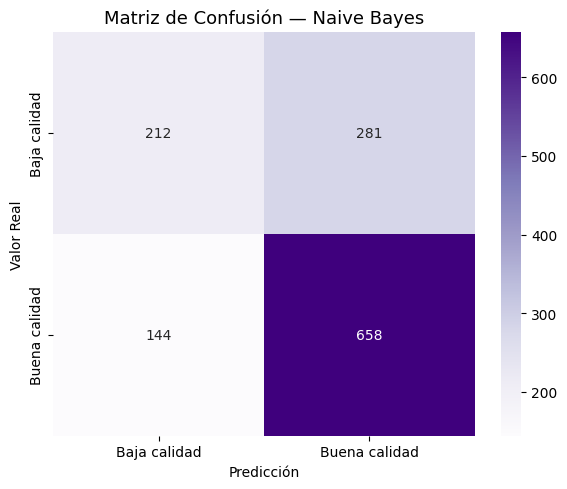

In [ ]:
# 7. Visualización de la Matriz de Confusión — Naive Bayes
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Baja calidad', 'Buena calidad'],
            yticklabels=['Baja calidad', 'Buena calidad'])
plt.title('Matriz de Confusión — Naive Bayes', fontsize=13)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

#MODELO 2: CLUSTERING K-MEANS (Agrupamiento)

## ¿Por qué K-Means?
El modelo de K-Means es un método de aprendizaje **no supervisado** utilizado para descubrir grupos o **patrones ocultos en los datos**, sin conocer previamente las clases o categorías.

**Objetivo del análisis:** Detectar grupos de vinos con características físico-químicas similares para segmentar el portafolio de productos de la empresa.

**Variables utilizadas (solo numéricas):** `alcohol`, `volatile acidity`, `sulphates`, `citric acid`, `residual sugar`, `pH`, `density`

In [ ]:
# 1. Selección de variables para K-Means (solo numéricas)
variables_kmeans = ['alcohol', 'volatile acidity', 'sulphates',
                    'citric acid', 'residual sugar', 'pH', 'density']

XDB_km = df[variables_kmeans + ['quality_label']].dropna()

# Separar variables predictoras y objetivo
XD_km = XDB_km[variables_kmeans]
YD_km = XDB_km[['quality_label']]

# Codificar variable de salida
le_km = LabelEncoder()
YD_km_encoded = le_km.fit_transform(YD_km.values.ravel())

print('Mapeo de categorías de quality_label:')
for i, clase in enumerate(le_km.classes_):
    print(f'{i} → {"Baja calidad" if clase == 0 else "Buena calidad"}')

Mapeo de categorías de quality_label:
0 → Baja calidad
1 → Buena calidad


In [ ]:
# 2. Estandarización de variables (necesario para K-Means)
scaler = StandardScaler()
XD_km_scaled = scaler.fit_transform(XD_km)
print('Variables estandarizadas correctamente')

Variables estandarizadas correctamente


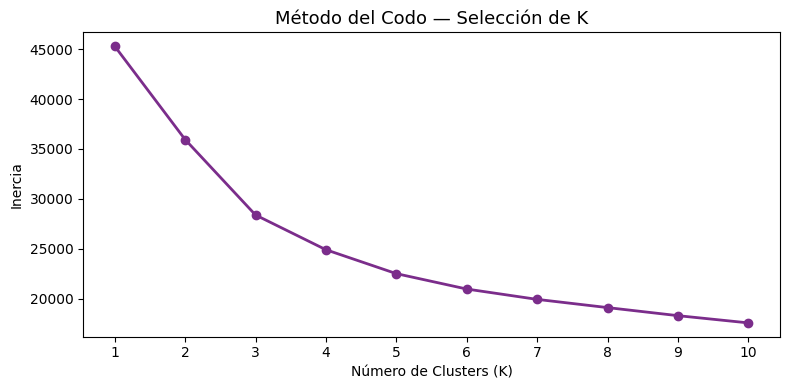

In [ ]:
# 3. Método del Codo para elegir el número óptimo de clusters
inercia = []
rango_k = range(1, 11)

for k in rango_k:
    km_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_temp.fit(XD_km_scaled)
    inercia.append(km_temp.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(rango_k, inercia, marker='o', color='#7B2D8B', linewidth=2)
plt.title('Método del Codo — Selección de K', fontsize=13)
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia')
plt.xticks(rango_k)
plt.tight_layout()
plt.show()

In [ ]:
# 4. Crear modelo K-Means con K=3
np.random.seed(42)
nc = 3  # Número de clusters
mkm = KMeans(n_clusters=nc, random_state=42, n_init=10)
mkm.fit(XD_km_scaled)

# Centroides
centroides = mkm.cluster_centers_
print('Centroides de los clusters:\n', centroides)

# Etiquetas de cluster para cada muestra
labels = mkm.labels_
XDB_km = XDB_km.copy()
XDB_km['Cluster'] = labels

# Conteo de vinos por cluster
ND = np.bincount(labels)
print('\nNúmero de vinos por cluster:\n', ND)

Centroides de los clusters:
 [[-0.22343593  1.24177268  0.7921455  -0.65634501 -0.57262928  0.73380601
   0.56700335]
 [ 0.65689216 -0.4286234  -0.24965364  0.12487214 -0.48762028 -0.09504701
  -0.86449676]
 [-0.76720999 -0.34237242 -0.25238758  0.32631864  1.13752299 -0.42853495
   0.79973674]]

Número de vinos por cluster:
 [1555 2893 2023]


In [ ]:
# 5. Distribución de calidad por cluster
NBaja = XDB_km.groupby('Cluster').agg({'quality_label': lambda x: (x == 0).sum()})
NBuena = XDB_km.groupby('Cluster').agg({'quality_label': lambda x: (x == 1).sum()})

NBaja['Baja calidad %']  = NBaja['quality_label'] / ND * 100
NBuena['Buena calidad %'] = NBuena['quality_label'] / ND * 100

print('\nPorcentaje de vinos de BAJA calidad por cluster:\n', NBaja[['Baja calidad %']].round(1))
print('\nPorcentaje de vinos de BUENA calidad por cluster:\n', NBuena[['Buena calidad %']].round(1))


Porcentaje de vinos de BAJA calidad por cluster:
          Baja calidad %
Cluster                
0                  52.7
1                  22.2
2                  45.2

Porcentaje de vinos de BUENA calidad por cluster:
          Buena calidad %
Cluster                 
0                   47.3
1                   77.8
2                   54.8


In [ ]:
# 6. Análisis de centroides en escala original
centroides_original = scaler.inverse_transform(centroides)
df_centroides = pd.DataFrame(centroides_original, columns=variables_kmeans)
df_centroides.index.name = 'Cluster'
print('\nCentroides en escala original:')
print(df_centroides.round(3))


Centroides en escala original:
         alcohol  volatile acidity  sulphates  citric acid  residual sugar  \
Cluster                                                                      
0         10.227             0.544      0.649        0.223           2.722   
1         11.277             0.269      0.494        0.337           3.126   
2          9.578             0.283      0.494        0.366          10.858   

            pH  density  
Cluster                  
0        3.336    0.996  
1        3.203    0.992  
2        3.149    0.997  


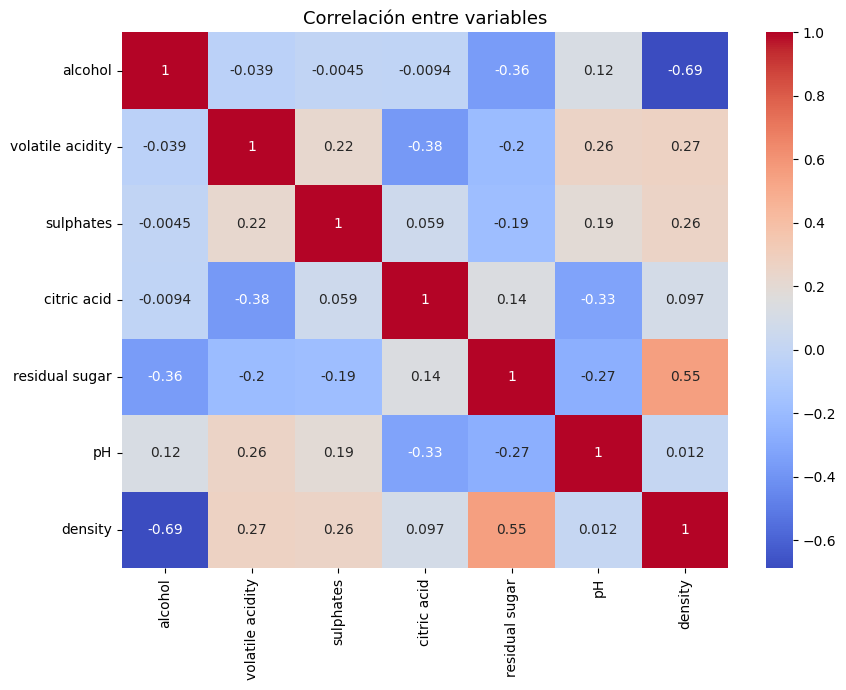

In [ ]:
# 7. Visualización: Mapa de correlación entre variables
plt.figure(figsize=(9, 7))
sns.heatmap(XD_km.corr(), annot=True, cmap='coolwarm')
plt.title('Correlación entre variables', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# 9. Ejemplo de predicción: asignar cluster a un vino nuevo
# Ajustar cluster_to_class según el análisis de los centroides
cluster_to_class = {0: 1, 1: 0, 2: 1}  # Ajustar según resultados del codo

ydp = np.zeros(len(XD_km), dtype=int)
for k in range(len(XD_km)):
    cluster = labels[k]
    ydp[k] = cluster_to_class[cluster]

# Evaluar desempeño
cm_km = confusion_matrix(YD_km_encoded, ydp)
print('Matriz de confusión K-Means:\n', cm_km)

print('\nReporte de clasificación:')
print(classification_report(YD_km_encoded, ydp,
      target_names=['Baja calidad', 'Buena calidad']))

print('Exactitud global:', round(accuracy_score(YD_km_encoded, ydp) * 100, 1), '%')

Matriz de confusión K-Means:
 [[ 641 1735]
 [2252 1843]]

Reporte de clasificación:
               precision    recall  f1-score   support

 Baja calidad       0.22      0.27      0.24      2376
Buena calidad       0.52      0.45      0.48      4095

     accuracy                           0.38      6471
    macro avg       0.37      0.36      0.36      6471
 weighted avg       0.41      0.38      0.39      6471

Exactitud global: 38.4 %


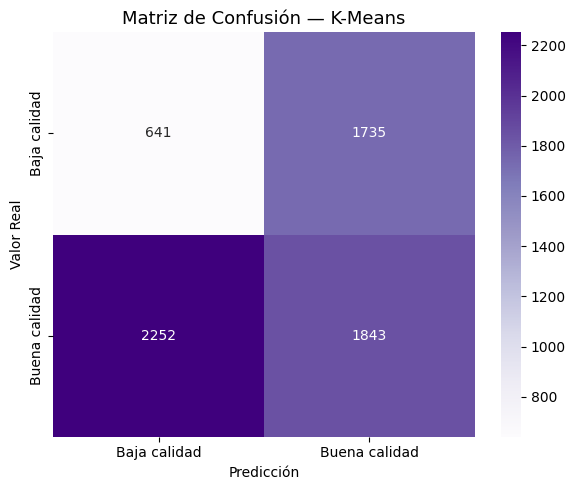

In [ ]:
# 10. Visualización de la Matriz de Confusión — K-Means
plt.figure(figsize=(6, 5))
sns.heatmap(cm_km, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Baja calidad', 'Buena calidad'],
            yticklabels=['Baja calidad', 'Buena calidad'])
plt.title('Matriz de Confusión — K-Means', fontsize=13)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()